In [1]:
import pandas as pd 
import numpy as np
import os
import sys
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt
SEED = 42

In [2]:
ls = os.listdir()
if 'data' not in ls:
    os.mkdir('data')

In [3]:
abs_path = os.path.abspath('data')
df_bee = pd.read_csv(abs_path + '/bee_features.csv')
df_bee.head()

,ID,R_min,R_max,R_mean,R_median,R_std,G_min,G_max,G_mean,G_median,G_std,B_min,B_max,B_mean,B_median,B_std,pixel_ratio,area,perimeter,circularity_laplacian,bounding_box_ratio,center_mass_x,center_mass_y,bug type,species
0,1,5,208,68.085745,56.0,47.955399,3,199,54.882747,37.0,45.311197,0,193,39.891969,24.0,36.250747,0.007428,178273,8998,0.027670,1.223881,3035.244911,2222.120394,Bee,Apis mellifera
1,2,2,248,63.786498,55.0,42.153508,2,251,52.079650,34.0,42.866124,0,244,35.735147,19.0,34.617117,0.008553,205272,9494,0.028618,1.514286,3032.674607,1698.048360,Bee,Apis mellifera
2,3,3,255,107.176333,114.0,58.771359,0,255,87.794710,86.0,60.057604,0,255,63.383043,52.0,54.823596,0.022093,530235,11818,0.047708,1.060606,2714.310953,1137.948478,Bee,Apis mellifera
3,4,5,219,87.588243,88.0,46.322587,3,213,71.031852,61.0,46.085760,0,201,50.432535,36.0,37.445621,0.013187,316497,12385,0.025929,1.308511,3486.890675,2223.213951,Bee,Apis mellifera
4,5,6,255,123.177003,134.0,62.355944,0,250,100.897964,91.0,63.029355,0,245,80.946170,63.0,60.624962,0.009165,219951,7870,0.044626,1.200000,2867.283645,2195.199194,Bee,Apis mellifera


In [4]:
def scrollable_table(train_df, title, table_id):
    """
    Function to create a scrollable table for the train and test dataframes.
    """
    from IPython.display import display, HTML
    html = f"""
    <div id="{table_id}" style="height:300px; overflow:auto;">
        <h3>{title}</h3>
        {train_df.to_html()}
        <h3>Test Data</h3>
    </div>
    """
    display(HTML(html))

In [5]:
df_num = df_bee.select_dtypes(include=['float64', 'int64'])
df_num.describe().T
html_num = scrollable_table(df_num.describe().T, "Numerical Features", "Summary statistics for numerical features")
display(html_num)

,count,mean,std,min,25%,50%,75%,max
ID,249.0,125.385542,72.435928,1.000000,63.000000,125.000000,188.000000,2.500000e+02
R_min,249.0,5.084337,5.989651,0.000000,0.000000,3.000000,7.000000,3.700000e+01
R_max,249.0,248.935743,14.904396,168.000000,255.000000,255.000000,255.000000,2.550000e+02
R_mean,249.0,100.572496,30.036167,44.072200,79.300262,95.337120,119.047545,2.151956e+02
R_median,249.0,95.967871,36.790040,24.000000,72.000000,93.000000,118.000000,2.350000e+02
R_std,249.0,54.082349,8.229751,35.345836,48.481372,53.409697,59.432282,8.331520e+01
G_min,249.0,1.995984,3.991420,0.000000,0.000000,0.000000,3.000000,3.100000e+01
G_max,249.0,243.835341,20.678828,170.000000,242.000000,255.000000,255.000000,2.550000e+02
G_mean,249.0,82.199375,29.077955,22.564004,63.560856,77.065526,97.708370,2.133181e+02
G_median,249.0,75.373494,36.245593,13.000000,51.000000,69.000000,96.000000,2.330000e+02


None

In [6]:
df_cat = df_bee.select_dtypes(include=['object'])
df_cat.describe().T
html_cat = scrollable_table(df_cat.describe().T, "Categorical Features", "Summary statistics for categorical features")
display(html_cat)

,count,unique,top,freq
bug type,249,6,Bee,115
species,249,24,Bombus hortorum,71


None

In [7]:
df_cat['bug type'].value_counts()

bug type
Bee          115
Bumblebee    100
Butterfly     15
Hover fly      9
Wasp           9
Dragonfly      1
Name: count, dtype: int64

## Data Pipeline

In [63]:
## The purpose of this data pipeline is to automate and standardize the processig 
## for bee classification based on the features in the dataset.

In [8]:
num_transform = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_transform = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')), # we don't have any missing value in this case
    ('onehot', sklearn.preprocessing.OneHotEncoder(handle_unknown='ignore'))
])

In [9]:
num_columns = df_bee.select_dtypes(include=['float64', 'int64']).columns
cat_columns = df_bee.select_dtypes(include=['object', 'category']).columns

cat_columns = cat_columns.drop('bug type')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transform, num_columns),
        ('cat', cat_transform, cat_columns)
    ],
    remainder='passthrough'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
])

le = sklearn.preprocessing.LabelEncoder()
X = df_bee.drop('bug type', axis=1)
y_encoded = le.fit_transform(df_bee['bug type'])

X_preprocessed = pipeline.fit_transform(X)

In [10]:
print(y_encoded)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 4 4 4
 0 4 0 5 5 5 5 3 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 2 1 0 0 0 0 0 0 0 0 0 0 0 1 1 4 1 1 0 0 4 4 1 1 1 5 0 0 1 0 0 1
 0 2 2 1 0 2 2 0 0 0 0 0 0 1 1 1 4 1 1 0 2 2 1 1 0 0 0 1 1 1 0 1 1 1 1 1 0
 2 2 1 1 1 0 1 0 0 0 2 0 2 2 2 5 5 5 5 0 0 0 0 0 0 0 0]


In [14]:
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import  train_test_split

In [18]:
mask = y_encoded != 3 # Assuming '3' is the label for 'other' or unwanted class say good by to outliers
X_preprocessed = X_preprocessed[mask]
y_encoded = le.fit_transform(y_encoded[mask])
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y_encoded, test_size=0.2, random_state=SEED, stratify=y_encoded)

models = {
    'XGB': XGBClassifier(random_state=SEED),
    'RF': RandomForestClassifier(random_state=SEED),
    'AB': AdaBoostClassifier(random_state=SEED),
    'SVC': SVC(random_state=SEED, probability=True)
}

#hyperparameters
params = {
    'XGB': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1]
    },
    'RF': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 4],
        'max_features': ['sqrt', 'log2']
    },
    'SVC': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto']
    },
    'AB':{
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 1.0],
    }
}

kf =StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED) #Using StratifiedKFold to maintain the distribution of classes in each fold whe have imbalanced classes

grid = {}
for name, model in models.items():
    print(f"Training {name} model...")
    grid[name] = GridSearchCV(model, cv=kf, param_grid=params[name], scoring='accuracy', n_jobs=-1, verbose=1)
    grid[name].fit(X_train, y_train)
    best_params = grid[name].best_params_
    best_score = grid[name].best_score_
    print(f"Best parameters for {name}: {best_params}")
    print(f"Best accuracy for {name}: {best_score} \n")

Training XGB model...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for XGB: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Best accuracy for XGB: 0.9566066066066066 

Training RF model...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for RF: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 4, 'n_estimators': 100}
Best accuracy for RF: 0.9674174174174175 

Training AB model...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters for AB: {'learning_rate': 0.1, 'n_estimators': 100}
Best accuracy for AB: 0.934984984984985 

Training SVC model...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters for SVC: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best accuracy for SVC: 0.9783783783783784 



In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

for i in grid.keys():

    print(i + '', 'rms :',np.sqrt(mean_squared_error(y_test, grid[i].predict(X_test))),'mae :', mean_absolute_error(y_test, grid[i].predict(X_test)),'R2 score :', r2_score(y_test, grid[i].predict(X_test)))
    print('')

XGB rms : 0.3296902366978935 mae : 0.06521739130434782 R2 score : 0.7110552763819096

RF rms : 0.39009474880274697 mae : 0.10869565217391304 R2 score : 0.5954773869346732

AB rms : 0.531609533071195 mae : 0.15217391304347827 R2 score : 0.24874371859296474

SVC rms : 0.3611575592573076 mae : 0.08695652173913043 R2 score : 0.6532663316582914



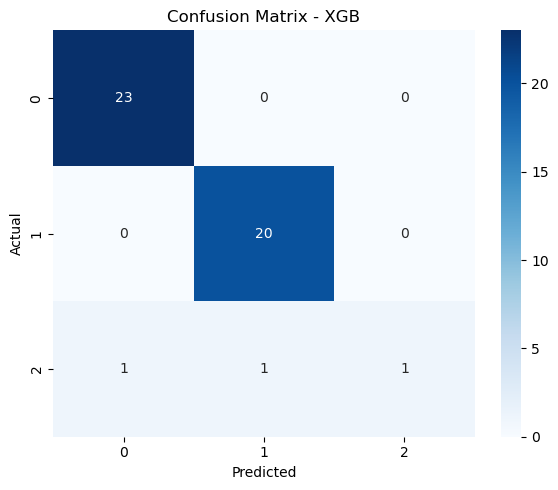

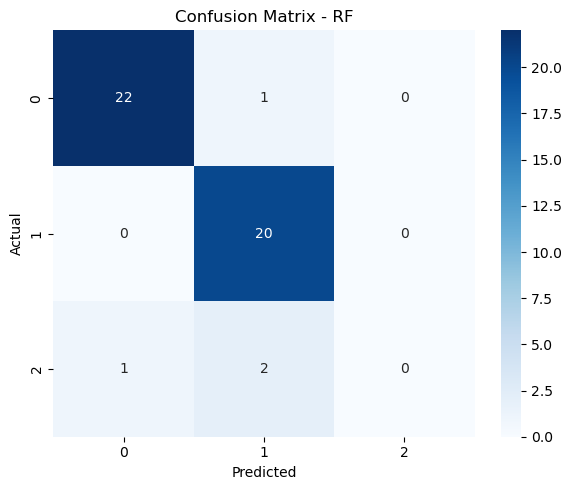

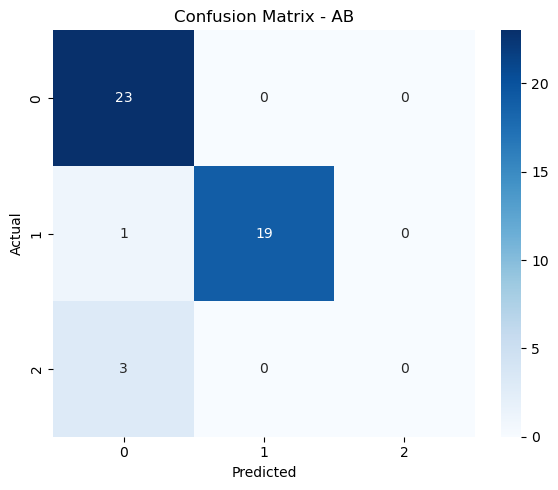

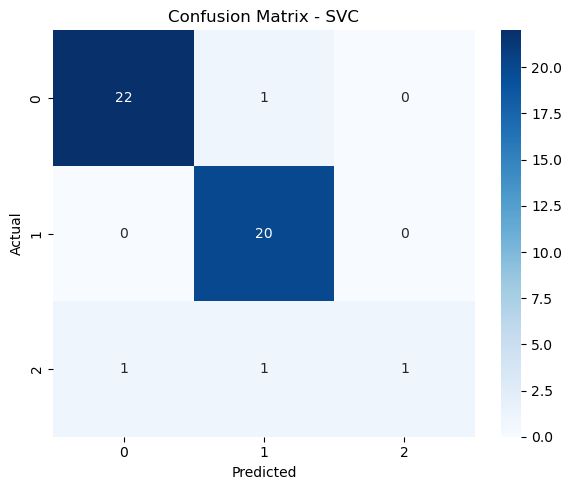

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_labels = le.classes_  # from LabelEncoder

def plot_confusion_matrix(model_name, y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

for name, model in grid.items():
    y_pred = model.predict(X_test)
    plot_confusion_matrix(name, y_test, y_pred, class_labels)

In [24]:
from sklearn.metrics import classification_report

for name, model in grid.items():
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       0.95      1.00      0.98        20
           2       1.00      0.33      0.50         3

    accuracy                           0.96        46
   macro avg       0.97      0.78      0.82        46
weighted avg       0.96      0.96      0.95        46



c:\Users\mugan\miniconda3\envs\ds_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mugan\miniconda3\envs\ds_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mugan\miniconda3\envs\ds_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        23
           1       0.87      1.00      0.93        20
           2       0.00      0.00      0.00         3

    accuracy                           0.91        46
   macro avg       0.61      0.65      0.63        46
weighted avg       0.86      0.91      0.88        46

              precision    recall  f1-score   support

           0       0.85      1.00      0.92        23
           1       1.00      0.95      0.97        20
           2       0.00      0.00      0.00         3

    accuracy                           0.91        46
   macro avg       0.62      0.65      0.63        46
weighted avg       0.86      0.91      0.88        46

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        23
           1       0.91      1.00      0.95        20
           2       1.00      0.33      0.50         3

    accuracy        

c:\Users\mugan\miniconda3\envs\ds_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mugan\miniconda3\envs\ds_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from joblib import dump

model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

for name, model in grid.items():
    model_path = os.path.join(model_dir, f'{name.lower()}_model.joblib')
    dump(model, model_path)
    print(f"Model {name.lower()} saved to {model_path}")